In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
import glob
import json

### plotting functions

In [2]:
plt.rcParams['figure.dpi'] = 200

In [3]:
pugy = LinearSegmentedColormap.from_list('pugy', np.concatenate([matplotlib.colormaps["RdGy_r"](np.arange(0.2, 0.5, .04)), 
                matplotlib.colormaps["PiYG_r"](np.arange(0.5, 0.85, .04))]), N = 10)

brown_col = matplotlib.colormaps["BrBG"](np.linspace(0., 0.499, 64))
blue_col = matplotlib.colormaps["RdBu"](np.linspace(0.501, 1, 64))
brownblue_col = np.vstack((brown_col, blue_col))
brbl = LinearSegmentedColormap.from_list('brbl', brownblue_col)

bupu = LinearSegmentedColormap.from_list('bupu', matplotlib.colormaps["BuPu"](np.arange(0, 1.1, .1)), N = 10)
oranges = LinearSegmentedColormap.from_list('oranges', matplotlib.colormaps["Oranges"](np.arange(0, 1.1, .1)), N = 9)
reds = LinearSegmentedColormap.from_list('reds', matplotlib.colormaps["Reds"](np.arange(0, 1.1, .1)), N = 11)

In [4]:
from statsmodels.distributions.empirical_distribution import ECDF

In [5]:
def ecdf_func(cmip, obs):
    if np.isnan(cmip).all():
        return(np.nan)
    if np.isnan(obs):
        return(np.nan)
    cmip = cmip[~np.isnan(cmip)]
    
    return (ECDF(cmip)(obs))

def ecdf_xr(cmip, obs):       
    return xr.apply_ufunc(ecdf_func, cmip, obs, 
                          input_core_dims = (["model_variant"], []), 
                          dask = "allowed", 
                          vectorize = True, ## required when function can only take 1D array
                         )

In [6]:
def plot_map(dat, lons, lats, ax, CMAP = None, VMIN = None, VMAX = None, na_col = "gainsboro", 
            label = None, legend = True):
    """ """
    if CMAP is None: 
        CMAP = "viridis"
    
    ax.set_facecolor(na_col)
    
    if VMIN is not None:
        p = ax.pcolormesh(lons, lats, dat, vmin = VMIN, vmax = VMAX, transform = ccrs.PlateCarree(), 
                          cmap = CMAP)
    else: 
        p = ax.pcolormesh(lons, lats, dat, transform = ccrs.PlateCarree(), cmap = CMAP)
    
    ax.add_feature(cfeature.LAND.with_scale('110m'), facecolor = na_col)
    ax.add_feature(cfeature.COASTLINE.with_scale('110m'), linewidth = 0.5)   
    if (label is not None) and (legend): 
        cb = plt.colorbar(p, ax = ax, shrink = 0.7, pad = 0.05, location = "bottom")
        cb.set_label(label=label,size = 16)
    elif legend: 
        plt.colorbar(p, ax = ax, shrink = 0.7, location = "bottom")

    ax.set_extent((-180, 180, -90, 90), crs=ccrs.PlateCarree())
    return(p)

### read in data

In [7]:
start = 1979
end = 2020

In [8]:
dir = "../mnt_processed_data/"

In [9]:
cpc_trend = xr.open_dataset(dir+"cpc_trends/cpc_rx1day_"+str(start)+"-"+str(end)+"_trend.nc")
cpc_stat = xr.open_dataset(dir+"cpc_stats/cpc_rx1day_"+str(start)+"-"+str(end)+"_stats.nc")
cpc_trend_percent = (cpc_trend.sel(predictions = "coeff").value*10)/cpc_stat.mu*100

In [10]:
gpcc_trend = xr.open_dataset(dir+"gpcc_trends/gpcc_mon-p095_"+str(start)+"-"+str(end)+"_trend.nc")
gpcc_stat = xr.open_dataset(dir+"gpcc_stats/gpcc_mon-p095_"+str(start)+"-"+str(end)+"_stats.nc")
gpcc_trend_percent = (gpcc_trend.sel(predictions = "coeff").value*10)/gpcc_stat.p95*100

In [11]:
gpcp_trend = xr.open_dataset(dir+"gpcp_trends/gpcp_mon-p095_"+str(start)+"-"+str(end)+"_trend.nc")
gpcp_stat = xr.open_dataset(dir+"gpcp_stats/gpcp_mon-p095_"+str(start)+"-"+str(end)+"_stats.nc")
gpcp_trend_percent = (gpcp_trend.sel(predictions = "coeff").value*10)/gpcp_stat.p95*100

In [12]:
mswep_rx1day_trend = xr.open_dataset(dir+"mswep_trends/mswep_rx1day_"+str(start)+"-"+str(end)+"_trend.nc")
mswep_rx1day_stat = xr.open_dataset(dir+"mswep_stats/mswep_rx1day_"+str(start)+"-"+str(end)+"_stats.nc")
mswep_rx1day_trend_percent = (mswep_rx1day_trend.sel(predictions = "coeff").value*10)/mswep_rx1day_stat.mu*100

mswep_mon_trend = xr.open_dataset(dir+"mswep_trends/mswep_mon-p095_"+str(start)+"-"+str(end)+"_trend.nc")
mswep_mon_stat = xr.open_dataset(dir+"mswep_stats/mswep_mon-p095_"+str(start)+"-"+str(end)+"_stats.nc")
mswep_mon_trend_percent = (mswep_mon_trend.sel(predictions = "coeff").value*10)/mswep_mon_stat.p95*100

#### cmip

In [13]:
cmip_files = sorted(glob.glob(dir+"cmip_trends/cmip_rx1day_*_"+str(start)+"-"+str(end)+"_trend.nc"))
cmip_day_trends = []
for f in cmip_files:
    x = xr.open_dataset(f).assign_coords({"model_variant": f.split("/")[-1].split("_")[2]+"_"+\
                                                f.split("/")[-1].split("_")[3]})

    cmip_day_trends.append(x)

cmip_day_trends = xr.concat(cmip_day_trends, dim = "model_variant")

In [14]:
model_var_dict = json.load(open(dir+"model_var_dict.json"))

In [22]:
t = ['ACCESS-CM2_r1i1p1f1',
 'ACCESS-ESM1-5_r1i1p1f1',
 'BCC-CSM2-MR_r1i1p1f1',
 'CAMS-CSM1-0_r2i1p1f1',
 'CESM2_r11i1p1f1',
 'CESM2-WACCM_r1i1p1f1',
 'CMCC-CM2-SR5_r1i1p1f1',
 'CMCC-ESM2_r1i1p1f1',
 'CNRM-CM6-1_r1i1p1f2',
 'CNRM-ESM2-1_r1i1p1f2',
 'CanESM5_r1i1p1f1',
 'EC-Earth3_r1i1p1f1',
 'EC-Earth3-CC_r1i1p1f1',
 'EC-Earth3-Veg_r1i1p1f1',
 'EC-Earth3-Veg-LR_r1i1p1f1',
 'FGOALS-g3_r1i1p1f1',
 'GFDL-CM4_r1i1p1f1',
 'GFDL-ESM4_r1i1p1f1',
 'HadGEM3-GC31-LL_r1i1p1f3',
 'HadGEM3-GC31-MM_r1i1p1f3',
 'IITM-ESM_r1i1p1f1',
 'INM-CM4-8_r1i1p1f1',
 'INM-CM5-0_r1i1p1f1',
 'IPSL-CM6A-LR_r1i1p1f1',
 'KACE-1-0-G_r1i1p1f1',
 'KIOST-ESM_r1i1p1f1',
 'MIROC-ES2L_r10i1p1f2',
 'MIROC6_r1i1p1f1',
 'MPI-ESM1-2-LR_r1i1p1f1',
 'MRI-ESM2-0_r1i1p1f1',
 'NESM3_r1i1p1f1',
 'NorESM2-LM_r1i1p1f1',
 'NorESM2-MM_r1i1p1f1',
 'TaiESM1_r1i1p1f1',
 'UKESM1-0-LL_r1i1p1f2']

In [30]:
len(t)

35

In [26]:
a = cmip_day_trends.sel(model_variant = t).sel(predictions = "coeff").value.count(dim = "model_variant")

In [27]:
b = xr.where(~np.isnan(gpcc_trend_percent), a, np.nan)

In [36]:
c = xr.where(b < 35, 0, 1)
c = xr.where(~np.isnan(gpcc_trend_percent), c, np.nan)

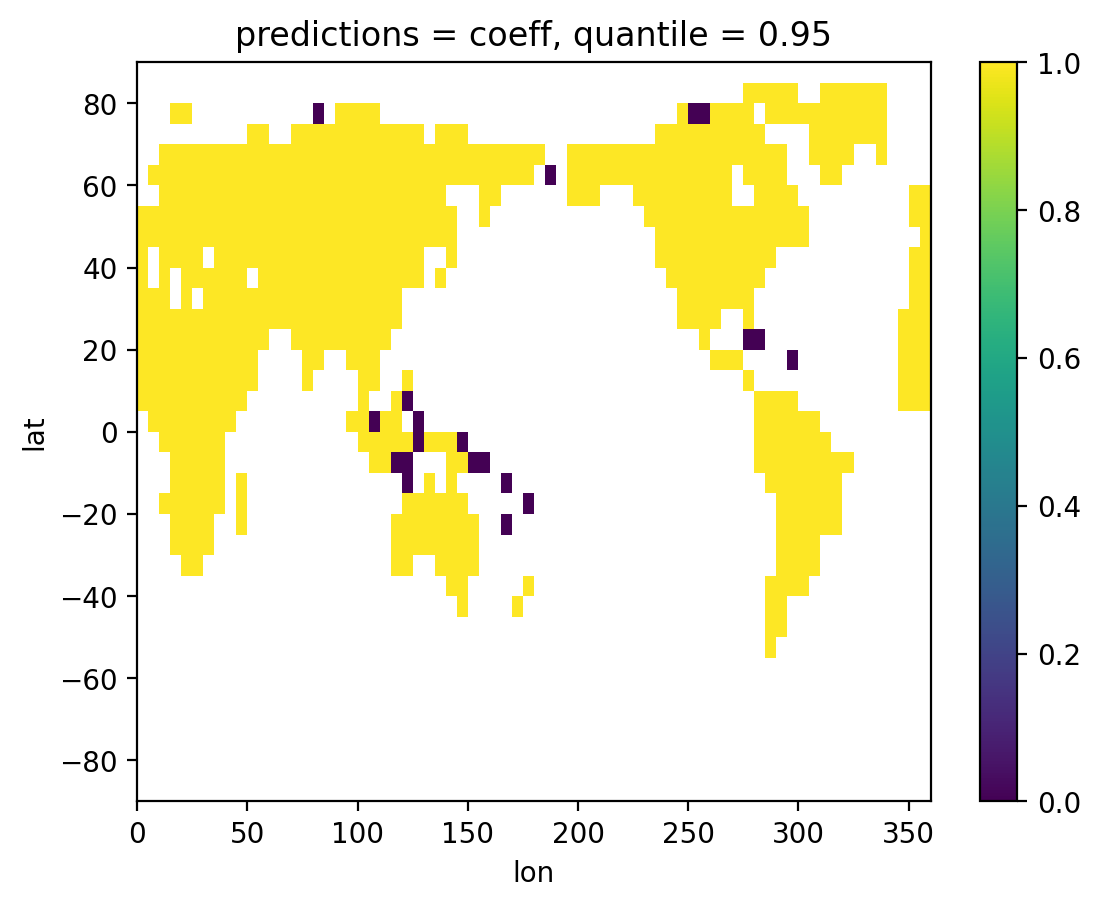

In [37]:
c.plot()

In [19]:
files = sorted(glob.glob(dir+"cmip_stats/cmip_rx1day_*_"+str(start)+"-"+str(end)+"_stats.nc"))
cmip_day_stat = []
for f in files:
    x = xr.open_dataset(f).assign_coords({"model_variant": f.split("/")[-1].split("_")[2]+"_"+\
                                                f.split("/")[-1].split("_")[3]})
    try:
        x = x.drop_vars("type")
    except:
        pass
    cmip_day_stat.append(x)
cmip_day_stat = xr.concat(cmip_day_stat, dim = "model_variant")

ValueError: must supply at least one object to concatenate

In [ ]:
cmip_day_trend_percent = (cmip_day_trends.sel(predictions = "coeff").value*10)/cmip_day_stat.mu*100

In [20]:
cmip_files = sorted(glob.glob(dir+"cmip_trends/cmip_mon-p095_*_"+str(start)+"-"+str(end)+"_trend.nc"))
cmip_mon_trends = []
for f in cmip_files:
    x = xr.open_dataset(f).assign_coords({"model_variant": f.split("/")[-1].split("_")[2]+"_"+\
                                                f.split("/")[-1].split("_")[3]})
    try:
        x = x.drop_vars("type")
    except:
        pass
    cmip_mon_trends.append(x)

cmip_mon_trends = xr.concat(cmip_mon_trends, dim = "model_variant")

files = sorted(glob.glob(dir+"cmip_stats/cmip_mon-p095_*_"+str(start)+"-"+str(end)+"_stats.nc"))
cmip_mon_stat = []
for f in files:
    x = xr.open_dataset(f).assign_coords({"model_variant": f.split("/")[-1].split("_")[2]+"_"+\
                                                f.split("/")[-1].split("_")[3]})
    try:
        x = x.drop_vars("type")
    except:
        pass
    cmip_mon_stat.append(x)
cmip_mon_stat = xr.concat(cmip_mon_stat, dim = "model_variant")

cmip_mon_trend_percent = (cmip_mon_trends.sel(predictions = "coeff").value*10)/cmip_mon_stat.p95*100

ValueError: must supply at least one object to concatenate

In [23]:
sorted(glob.glob(dir+"cmip_trends/cmip_mon-p095_*_"+str(start)+"-"+str(end)+"_trend.nc"))

[]

In [24]:
dir+"cmip_trends/cmip_mon-p095_*_"+str(start)+"-"+str(end)+"_trend.nc"

'../mnt_processed_data/cmip_trends/cmip_mon-p095_*_1979-2020_trend.nc'

In [ ]:
glob.glob("../mnt_processed_data/

#### mesaclip

In [17]:
sim_keys = ["001", "002", "003", "004", "005", "006", "007", "009", "010"]
mesaclip_day_trends = []
mesaclip_day_stats = []
mesaclip_mon_trends = []
mesaclip_mon_stats = []
for sim in sim_keys:
    x = xr.open_dataset(dir+"mesaclip_trends/mesaclip_rx1day_precip_"+sim+"_"+\
                        str(start)+"-"+str(end)+"_5x5_trend.nc").assign_coords({"sim": sim})
    mesaclip_day_trends.append(x)

    x = xr.open_dataset(dir+"mesaclip_stats/mesaclip_rx1day_precip_"+sim+"_"+\
                        str(start)+"-"+str(end)+"_5x5_stats.nc").assign_coords({"sim": sim})
    mesaclip_day_stats.append(x)

    x = xr.open_dataset(dir+"mesaclip_trends/mesaclip_mon-p095_"+sim+"_"+str(start)+"-"+str(end)+\
                        "_5x5_trend.nc").assign_coords({"sim": sim})
    mesaclip_mon_trends.append(x)

    x = xr.open_dataset(dir+"mesaclip_stats/mesaclip_mon-p095_"+sim+"_"+str(start)+"-"+str(end)+\
                        "_5x5_stats.nc").assign_coords({"sim": sim})
    mesaclip_mon_stats.append(x)

mesaclip_day_trends = xr.concat(mesaclip_day_trends, dim = "sim")
mesaclip_day_stats = xr.concat(mesaclip_day_stats, dim = "sim")
mesaclip_mon_trends = xr.concat(mesaclip_mon_trends, dim = "sim")
mesaclip_mon_stats = xr.concat(mesaclip_mon_stats, dim = "sim")

In [18]:
mesaclip_day_trend_percent = (mesaclip_day_trends.sel(predictions = "coeff").value*10)/mesaclip_day_stats.mu*100
mesaclip_mon_trend_percent = (mesaclip_mon_trends.sel(predictions = "coeff").value*10)/mesaclip_mon_stats.p95*100

#### spear

In [19]:
sim_keys = ["r"+str(r)+"i1p1f1" for r in np.arange(1, 31)]
spear_day_trends = []
spear_day_stats = []
spear_mon_trends = []
spear_mon_stats = []
for sim in sim_keys:
    x = xr.open_dataset(dir+"spear_trends/spear_rx1day_precip_"+sim+"_"+\
                        str(start)+"-"+str(end)+"_5x5_trend.nc").assign_coords({"sim": sim})
    spear_day_trends.append(x)

    x = xr.open_dataset(dir+"spear_stats/spear_rx1day_precip_"+sim+"_"+\
                        str(start)+"-"+str(end)+"_5x5_stats.nc").assign_coords({"sim": sim})
    spear_day_stats.append(x)

    x = xr.open_dataset(dir+"spear_trends/spear_mon-p095_"+sim+"_"+str(start)+"-"+str(end)+\
                        "_5x5_trend.nc").assign_coords({"sim": sim})
    spear_mon_trends.append(x)

    x = xr.open_dataset(dir+"spear_stats/spear_mon-p095_"+sim+"_"+str(start)+"-"+str(end)+\
                        "_5x5_stats.nc").assign_coords({"sim": sim})
    spear_mon_stats.append(x)

spear_day_trends = xr.concat(spear_day_trends, dim = "sim")
spear_day_stats = xr.concat(spear_day_stats, dim = "sim")
spear_mon_trends = xr.concat(spear_mon_trends, dim = "sim")
spear_mon_stats = xr.concat(spear_mon_stats, dim = "sim")

In [20]:
spear_day_trend_percent = (spear_day_trends.sel(predictions = "coeff").value*10)/spear_day_stats.mu*100
spear_mon_trend_percent = (spear_mon_trends.sel(predictions = "coeff").value*10)/spear_mon_stats.p95*100

In [21]:
model_var_dict = json.load(open(dir+"model_var_dict.json"))

In [55]:
ecdf_day_cmip_cpc = ecdf_xr(cmip_day_trend_percent.sel(model_variant = model_var_dict["cmip_day_onevar"]), cpc_trend_percent)
ecdf_day_spear_cpc = ecdf_xr(spear_day_trend_percent.rename({"sim": "model_variant"}), cpc_trend_percent)
ecdf_day_mesaclip_cpc = ecdf_xr(mesaclip_day_trend_percent.rename({"sim": "model_variant"}), cpc_trend_percent)

ecdf_mon_cmip_gpcc = ecdf_xr(cmip_mon_trend_percent.sel(model_variant = model_var_dict["cmip_mon_onevar"]), 
                   gpcc_trend_percent.sel(lat = slice(-58.75, 88.75)))
ecdf_mon_spear_gpcc = ecdf_xr(spear_mon_trend_percent.rename({"sim": "model_variant"}), gpcc_trend_percent)
ecdf_mon_mesaclip_gpcc = ecdf_xr(mesaclip_mon_trend_percent.rename({"sim": "model_variant"}), gpcc_trend_percent)

ecdf_mon_cmip_gpcp = ecdf_xr(cmip_mon_trend_percent.sel(model_variant = model_var_dict["cmip_mon_onevar"]), 
                   gpcp_trend_percent.sel(lat = slice(-58.75, 88.75)))
ecdf_mon_cmip_mswep = ecdf_xr(cmip_mon_trend_percent.sel(model_variant = model_var_dict["cmip_mon_onevar"]), 
                   mswep_mon_trend_percent.sel(lat = slice(-58.75, 88.75)))

ecdf_day_cmip_mswep = ecdf_xr(cmip_day_trend_percent.sel(model_variant = model_var_dict["cmip_day_onevar"]), mswep_rx1day_trend_percent)

In [23]:
ecdf_day_test_cmip = []
ecdf_mon_test_cmip = []

## cmip resampling
for mv in model_var_dict["cmip_day_onevar"]:
    a = xr.concat([cmip_day_trend_percent.sel(model_variant = model_var_dict["cmip_day_onevar"]).drop(labels = mv, dim = "model_variant"),
          cpc_trend_percent.expand_dims({"model_variant": ["obs"]})], dim = "model_variant")
    b = cmip_day_trend_percent.sel(model_variant = mv)
    x = ecdf_xr(a, b)
    ecdf_day_test_cmip.append([(x == 0).sum().values, (x == 1).sum().values, (b > 0).sum().values, b.count().values])

for mv in model_var_dict["cmip_mon_onevar"]:
    a = xr.concat([cmip_mon_trend_percent.sel(model_variant = model_var_dict["cmip_mon_onevar"]).drop(labels = mv, dim = "model_variant"),
          gpcc_trend_percent.sel(lat = slice(-58.75, 88.75)).expand_dims({"model_variant": ["obs"]})], dim = "model_variant")
    b = cmip_mon_trend_percent.sel(model_variant = mv)
    x = ecdf_xr(a, b)
    ecdf_mon_test_cmip.append([(x == 0).sum().values, (x == 1).sum().values, (b > 0).sum().values, b.count().values])

ecdf_day_test_cmip = pd.DataFrame(ecdf_day_test_cmip, columns = ["ecdf_0", "ecdf_1", "pos_trends", "num_values"])
ecdf_mon_test_cmip = pd.DataFrame(ecdf_mon_test_cmip, columns = ["ecdf_0", "ecdf_1", "pos_trends", "num_values"])

#### ecdf testing

In [ ]:
## create obs ecdf datasets

ecdf_obs_day = {}

## loop through obs datasets
for o in obs_list = 
## loop through model datasets


In [148]:
ecdf_day_test_cmip_full = []
ecdf_mon_test_cmip_full = []

## full cmip resampling
for mv in model_var_dict["cmip_day"]:
    a = xr.concat([cmip_day_trend_percent.drop(labels = mv, dim = "model_variant"),
          cpc_trend_percent.expand_dims({"model_variant": ["obs"]})], dim = "model_variant")
    b = cmip_day_trend_percent.sel(model_variant = mv)
    x = ecdf_xr(a, b)
    ecdf_day_test_cmip_full.append([(x == 0).sum().values, (x == 1).sum().values, (a > 0).sum()])

for mv in model_var_dict["cmip_mon"]:
    a = xr.concat([cmip_mon_trend_percent.drop(labels = mv, dim = "model_variant"),
          gpcc_trend_percent.sel(lat = slice(-58.75, 88.75)).expand_dims({"model_variant": ["obs"]})], dim = "model_variant")
    b = cmip_mon_trend_percent.sel(model_variant = mv)
    x = ecdf_xr(a, b)
    ecdf_mon_test_cmip_full.append([(x == 0).sum().values, (x == 1).sum().values, (a > 0).sum()])

## Figure 1

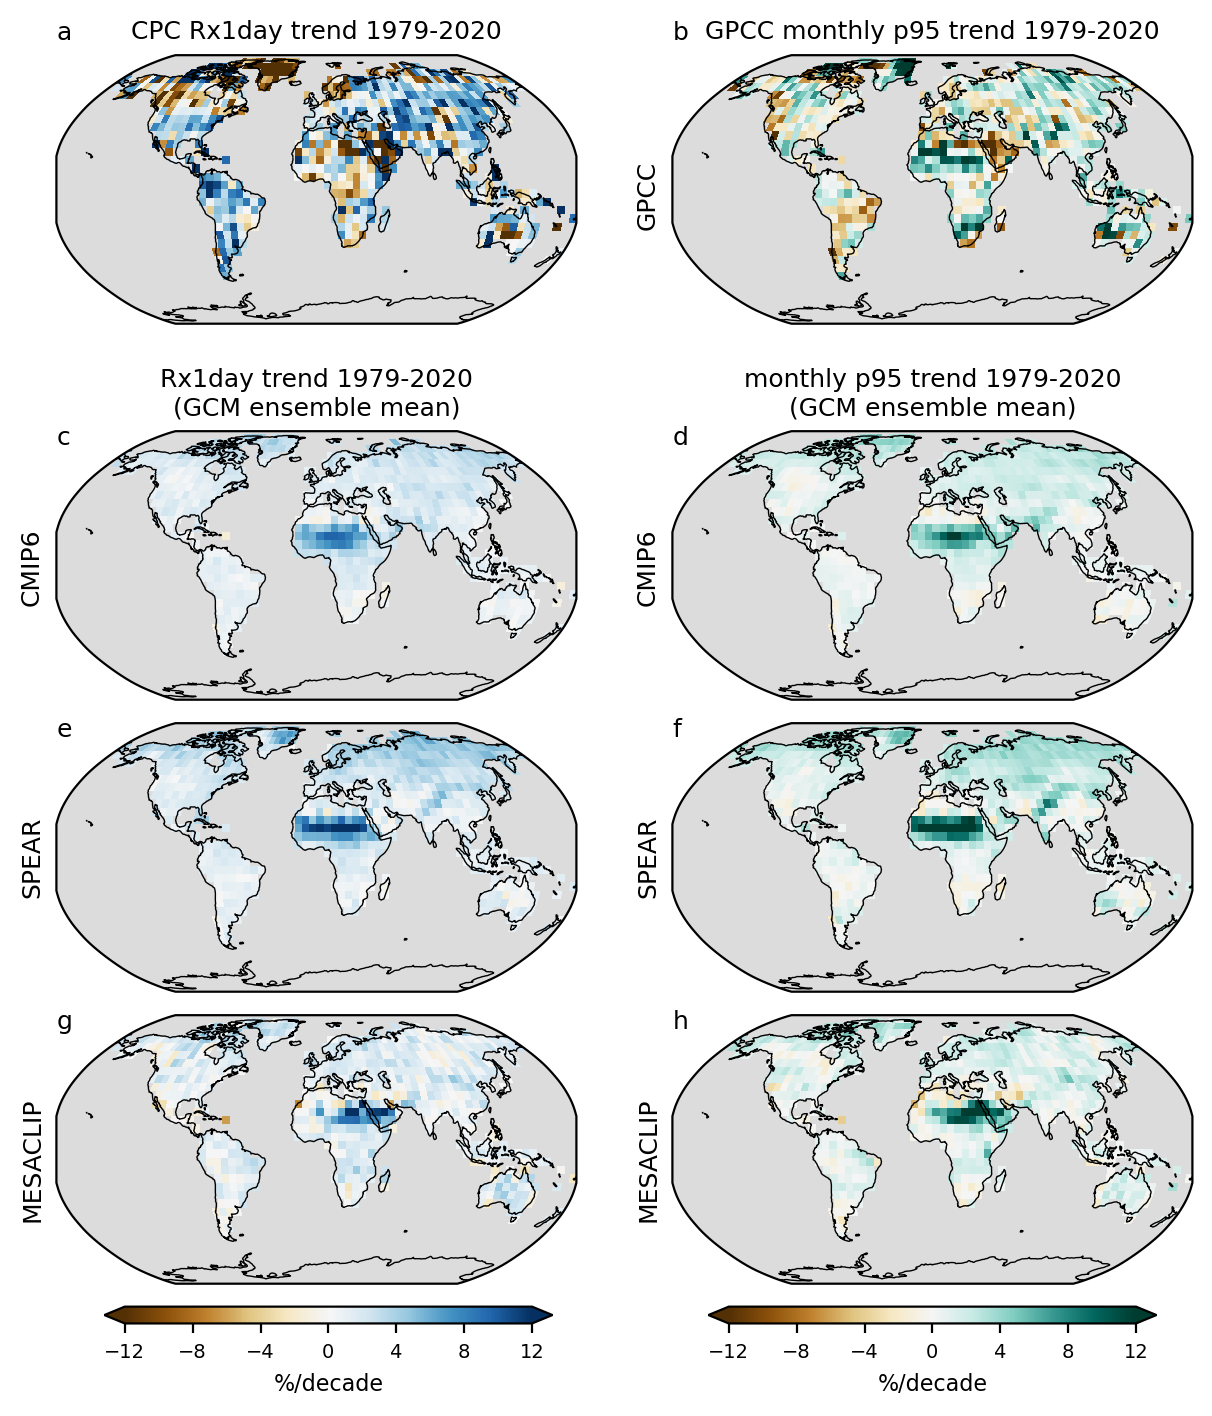

In [24]:
h_tot = 7
h = 1.6/h_tot
w_tot = 6
w = 2.6/w_tot

vmin = -12
vmax = 12
labelsize = 9
titlesize = 9

fig = plt.figure(figsize = (w_tot, h_tot))

## LEFT COLUMN
ax = fig.add_axes([.04, h*3+0.07, w, h], projection = ccrs.Robinson())
ax.set_title("CPC Rx1day trend 1979-2020", size = titlesize)
ax.text(0, 1.06, "a", size = titlesize, transform = ax.transAxes)
plot_map(cpc_trend_percent, 
             cpc_trend.lon, cpc_trend.lat, ax, legend = False,  
             CMAP = brbl, VMIN = vmin, VMAX = vmax)


ax = fig.add_axes([.04, h*2+0.03, w, h], projection = ccrs.Robinson())
ax.set_title("Rx1day trend 1979-2020\n(GCM ensemble mean)", size = titlesize)
ax.text(0, 0.95, "c", size = titlesize, transform = ax.transAxes)
ax.text(s = "CMIP6", x = -0.07, y = 0.37, transform = ax.transAxes, size = 9, rotation = "vertical")
plot_map(cmip_day_trend_percent.sel(model_variant = model_var_dict["cmip_day_onevar"]).mean(dim = "model_variant"), 
         cpc_trend.lon, cpc_trend.lat, ax, legend = False,  
             CMAP = brbl, VMIN = vmin, VMAX = vmax)

ax = fig.add_axes([.04, h+0.05, w, h], projection = ccrs.Robinson())
ax.text(0, 0.95, "e", size = titlesize, transform = ax.transAxes)
ax.text(s = "SPEAR", x = -0.07, y = 0.37, transform = ax.transAxes, size = 9, rotation = "vertical")
plot_map(spear_day_trend_percent.mean(dim = "sim"), 
         cpc_trend.lon, cpc_trend.lat, ax, legend = False,  
             CMAP = brbl, VMIN = vmin, VMAX = vmax)

ax = fig.add_axes([.04, 0.07, w, h], projection = ccrs.Robinson())
ax.text(0, 0.95, "g", size = titlesize, transform = ax.transAxes)
ax.text(s = "MESACLIP", x = -0.07, y = 0.25, transform = ax.transAxes, size = 9, rotation = "vertical")
p = plot_map(mesaclip_day_trend_percent.mean(dim = "sim"), 
         cpc_trend.lon, cpc_trend.lat, ax, legend = False,  
             CMAP = brbl, VMIN = vmin, VMAX = vmax)
cbaxes = fig.add_axes([.08, 0.06, w-0.06, 0.012]) 
cbar = fig.colorbar(p, cax = cbaxes, orientation = "horizontal", extend = "both", ticks=[-12, -8, -4, 0, 4, 8, 12])
cbar.set_label(label = '%/decade', size = 8)
cbar.ax.tick_params(labelsize=7)

## RIGHT COLUMN
ax = fig.add_axes([.12+w, h*3+0.07, w, h], projection = ccrs.Robinson())
ax.text(s = "GPCC", x = -0.07, y = 0.37, transform = ax.transAxes, size = 9, rotation = "vertical")
ax.text(0, 1.06, "b", size = titlesize, transform = ax.transAxes)
ax.set_title("GPCC monthly p95 trend 1979-2020", size = titlesize)
plot_map(gpcc_trend_percent, 
             gpcc_trend.lon, gpcc_trend.lat, ax, legend = False, 
             CMAP = "BrBG", VMIN = vmin, VMAX = vmax)

ax = fig.add_axes([.12+w, h*2+0.03, w, h], projection = ccrs.Robinson())
ax.set_title("monthly p95 trend 1979-2020\n(GCM ensemble mean)", size = titlesize)
ax.text(0, 0.95, "d", size = titlesize, transform = ax.transAxes)
ax.text(s = "CMIP6", x = -0.07, y = 0.37, transform = ax.transAxes, size = 9, rotation = "vertical")
plot_map(cmip_mon_trend_percent.sel(model_variant = model_var_dict["cmip_mon_onevar"]).mean(dim = "model_variant"), 
         cmip_mon_trend_percent.lon, cmip_mon_trend_percent.lat, ax, legend = False,  
             CMAP = "BrBG", VMIN = vmin, VMAX = vmax)

ax = fig.add_axes([.12+w, h+0.05, w, h], projection = ccrs.Robinson())
ax.text(s = "SPEAR", x = -0.07, y = 0.37, transform = ax.transAxes, size = 9, rotation = "vertical")
ax.text(0, 0.95, "f", size = titlesize, transform = ax.transAxes)
plot_map(spear_mon_trend_percent.mean(dim = "sim"), 
         cpc_trend.lon, cpc_trend.lat, ax, legend = False,  
             CMAP = "BrBG", VMIN = vmin, VMAX = vmax)

ax = fig.add_axes([.12+w, 0.07, w, h], projection = ccrs.Robinson())
ax.text(s = "MESACLIP", x = -0.07, y = 0.25, transform = ax.transAxes, size = 9, rotation = "vertical")
ax.text(0, 0.95, "h", size = titlesize, transform = ax.transAxes)
p = plot_map(mesaclip_mon_trend_percent.mean(dim = "sim"), 
         cpc_trend.lon, cpc_trend.lat, ax, legend = False,  
             CMAP = "BrBG", VMIN = vmin, VMAX = vmax)

cbaxes = fig.add_axes([.15+w, 0.06, w-0.06, 0.012]) 
cbar = fig.colorbar(p, cax = cbaxes, orientation = "horizontal", extend = "both", ticks=[-12, -8, -4, 0, 4, 8, 12])
cbar.set_label(label = '%/decade', size = 8)
cbar.ax.tick_params(labelsize=7)

plt.savefig("../figures/fig1.png", dpi = 600)

## Figure 2

In [31]:
print((ecdf_day_cmip_cpc == 0).sum().values)
print((ecdf_day_cmip_cpc == 0).sum().values/(cpc_trend_percent < 0).sum().values)
print((ecdf_day_cmip_cpc == 1).sum().values)
print((ecdf_day_cmip_cpc == 1).sum().values/(cpc_trend_percent > 0).sum().values)

126
0.4864864864864865
93
0.20484581497797358


In [32]:
(126+93)/713

0.3071528751753156

In [33]:
print((ecdf_mon_cmip_gpcc == 0).sum().values)
print((ecdf_mon_cmip_gpcc == 0).sum().values/(gpcc_trend_percent < 0).sum().values)
print((ecdf_mon_cmip_gpcc == 1).sum().values)
print((ecdf_mon_cmip_gpcc == 1).sum().values/(gpcc_trend_percent > 0).sum().values)

67
0.21474358974358973
38
0.09476309226932668


In [34]:
(67+38)/713

0.14726507713884993

In [35]:
(cpc_trend_percent > 0).sum().values/713

0.6367461430575035

In [36]:
(gpcc_trend_percent > 0).sum().values/713

0.5624123422159888

In [39]:
cmip_mon_trend_percent.sel(model_variant = model_var_dict["cmip_mon_onevar"])

<xarray.DataArray (model_variant: 39, lat: 30, lon: 72)> Size: 674kB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * lon            (lon) float64 576B 2.5 7.5 12.5 17.5 ... 347.5 352.5 357.5
  * lat            (lat) float64 240B -57.5 -52.5 -47.5 -42.5 ... 77.5 82.5 87.5
    predictions    <U13 52B 'coeff'
  * model_variant  (model_variant) <U25 4kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1...
    quantile       float64 8B 0.95

In [38]:
cmip_day_trend_percent.sel(model_variant = model_var_dict["cmip_day_onevar"])

<xarray.DataArray (model_variant: 36, lat: 36, lon: 72)> Size: 746kB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * lat            (lat) float64 288B -87.5 -82.5 -77.5 -72.5 ... 77.5 82.5 87.5
  * lon            (lon) float64 576B 2.5 7.5 12.5 17.5 ... 347.5 352.5 357.5
    predictions    <U9 36B 'coeff'
  * model_variant  (model_variant) <U25 4kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1...

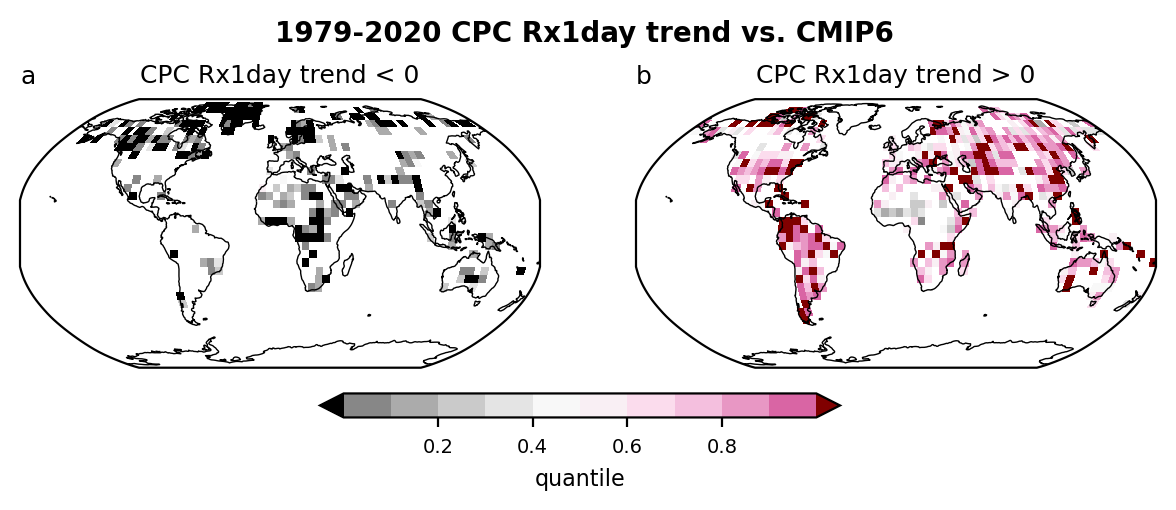

In [28]:
h_tot = 2.4
h = 1.6/h_tot
w_tot = 6
w = 2.6/w_tot

fig = plt.figure(figsize = (w_tot, h_tot))

## ROW 1 - Rx1day ECDF Maps
ax = fig.add_axes([.03, 0.2, w, h], projection = ccrs.Robinson())
ax.text(0, 1.06, "a", size = titlesize, transform = ax.transAxes)
ax.set_title("CPC Rx1day trend < 0", size = titlesize)
p = plot_map(xr.where(cpc_trend_percent < 0, ecdf_day_cmip_cpc, np.nan), 
             cpc_trend_percent.lon, cpc_trend_percent.lat, ax = ax, label = "quantile", 
         CMAP = pugy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
p.cmap.set_over("maroon")
p.cmap.set_under('black')

ax = fig.add_axes([.11+w, 0.2, w, h], projection = ccrs.Robinson())
ax.text(0, 1.06, "b", size = titlesize, transform = ax.transAxes)
ax.set_title("CPC Rx1day trend > 0", size = titlesize)
p = plot_map(xr.where(cpc_trend_percent > 0, ecdf_day_cmip_cpc, np.nan), 
             cpc_trend_percent.lon, cpc_trend_percent.lat, ax = ax, label = "quantile", 
         CMAP = pugy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
p.cmap.set_over("maroon")
p.cmap.set_under('black')

cbaxes = fig.add_axes([.28, 0.15, w, 0.05]) 
cbar = fig.colorbar(p, cax = cbaxes, orientation = "horizontal", extend = "both")
cbar.set_label(label = 'quantile', size = 8)
cbar.ax.tick_params(labelsize=7)

plt.suptitle("1979-2020 CPC Rx1day trend vs. CMIP6", size = 10, fontweight = "bold")

plt.savefig("../figures/ecdf_cmip_day.pdf")

In [ ]:
fig = plt.figure(figsize = (w_tot, h_tot))

## ROW 1 - Rx1day ECDF Maps
ax = fig.add_axes([.03, 0.2, w, h], projection = ccrs.Robinson())
ax.text(0, 1.06, "a", size = titlesize, transform = ax.transAxes)
ax.set_title("CPC Rx1day trend < 0", size = titlesize)
p = plot_map(xr.where(cpc_trend_percent < 0, ecdf_spear_day, np.nan), 
             cpc_trend_percent.lon, cpc_trend_percent.lat, ax = ax, label = "quantile", 
         CMAP = pugy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
p.cmap.set_over("maroon")
p.cmap.set_under('black')

ax = fig.add_axes([.11+w, 0.2, w, h], projection = ccrs.Robinson())
ax.text(0, 1.06, "b", size = titlesize, transform = ax.transAxes)
ax.set_title("CPC Rx1day trend > 0", size = titlesize)
p = plot_map(xr.where(cpc_trend_percent > 0, ecdf_spear_day, np.nan), 
             cpc_trend_percent.lon, cpc_trend_percent.lat, ax = ax, label = "quantile", 
         CMAP = pugy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
p.cmap.set_over("maroon")
p.cmap.set_under('black')

cbaxes = fig.add_axes([.28, 0.15, w, 0.05]) 
cbar = fig.colorbar(p, cax = cbaxes, orientation = "horizontal", extend = "both")
cbar.set_label(label = 'quantile', size = 8)
cbar.ax.tick_params(labelsize=7)

plt.suptitle("1979-2020 CPC Rx1day trend vs. SPEAR", size = 10, fontweight = "bold")

plt.savefig("../figures/ecdf_spear_day.png", dpi = 600)

In [ ]:
fig = plt.figure(figsize = (w_tot, h_tot))

## ROW 1 - Rx1day ECDF Maps
ax = fig.add_axes([.03, 0.2, w, h], projection = ccrs.Robinson())
ax.text(0, 1.06, "a", size = titlesize, transform = ax.transAxes)
ax.set_title("CPC Rx1day trend < 0", size = titlesize)
p = plot_map(xr.where(cpc_trend_percent < 0, ecdf_mesaclip_day, np.nan), 
             cpc_trend_percent.lon, cpc_trend_percent.lat, ax = ax, label = "quantile", 
         CMAP = pugy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
p.cmap.set_over("maroon")
p.cmap.set_under('black')

ax = fig.add_axes([.11+w, 0.2, w, h], projection = ccrs.Robinson())
ax.text(0, 1.06, "b", size = titlesize, transform = ax.transAxes)
ax.set_title("CPC Rx1day trend > 0", size = titlesize)
p = plot_map(xr.where(cpc_trend_percent > 0, ecdf_mesaclip_day, np.nan), 
             cpc_trend_percent.lon, cpc_trend_percent.lat, ax = ax, label = "quantile", 
         CMAP = pugy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
p.cmap.set_over("maroon")
p.cmap.set_under('black')

cbaxes = fig.add_axes([.28, 0.15, w, 0.05]) 
cbar = fig.colorbar(p, cax = cbaxes, orientation = "horizontal", extend = "both")
cbar.set_label(label = 'quantile', size = 8)
cbar.ax.tick_params(labelsize=7)

plt.suptitle("1979-2020 CPC Rx1day trend vs. MESACLIP", size = 10, fontweight = "bold")

plt.savefig("../figures/ecdf_mesaclip_day.png", dpi = 600)

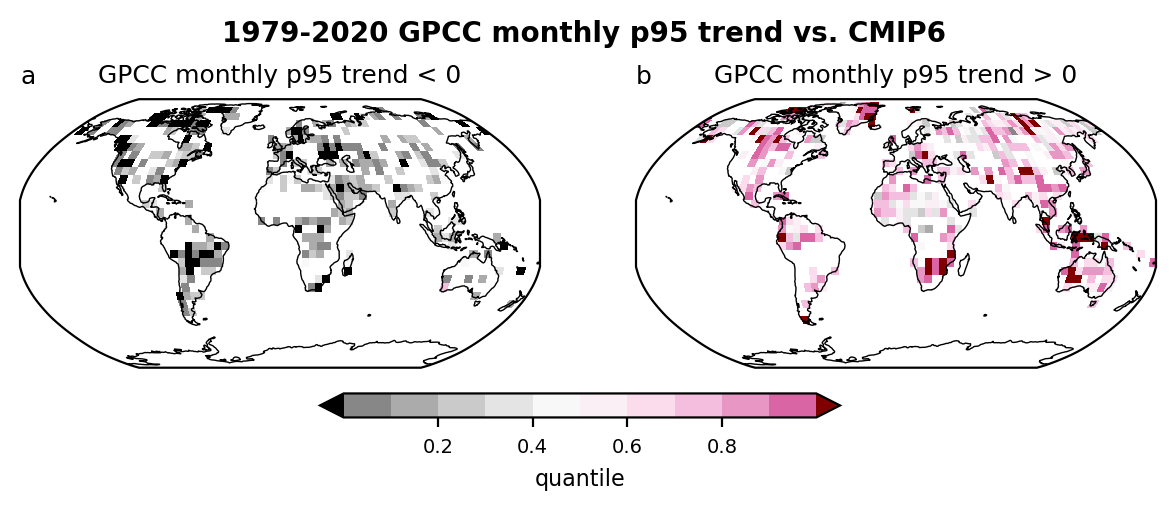

In [27]:
fig = plt.figure(figsize = (w_tot, h_tot))

## ROW 1
ax = fig.add_axes([.03, 0.2, w, h], projection = ccrs.Robinson())
ax.text(0, 1.06, "a", size = titlesize, transform = ax.transAxes)
ax.set_title("GPCC monthly p95 trend < 0", size = titlesize)
p = plot_map(xr.where(gpcc_trend_percent.sel(lat = slice(-58.75, 88.75)) < 0, ecdf_mon_cmip_gpcc, np.nan), 
             ecdf_mon_cmip_gpcc.lon, ecdf_mon_cmip_gpcc.lat, ax = ax, label = "quantile", 
         CMAP = pugy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
p.cmap.set_over("maroon")
p.cmap.set_under('black')

ax = fig.add_axes([.11+w, 0.2, w, h], projection = ccrs.Robinson())
ax.text(0, 1.06, "b", size = titlesize, transform = ax.transAxes)
ax.set_title("GPCC monthly p95 trend > 0", size = titlesize)
p = plot_map(xr.where(gpcc_trend_percent.sel(lat = slice(-58.75, 88.75)) > 0, ecdf_mon_cmip_gpcc, np.nan), 
             ecdf_mon_cmip_gpcc.lon, ecdf_mon_cmip_gpcc.lat, ax = ax, label = "quantile", 
         CMAP = pugy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
p.cmap.set_over("maroon")
p.cmap.set_under('black')

cbaxes = fig.add_axes([.28, 0.15, w, 0.05]) 
cbar = fig.colorbar(p, cax = cbaxes, orientation = "horizontal", extend = "both")
cbar.set_label(label = 'quantile', size = 8)
cbar.ax.tick_params(labelsize=7)

plt.suptitle("1979-2020 GPCC monthly p95 trend vs. CMIP6", size = 10, fontweight = "bold")

plt.savefig("../figures/ecdf_cmip_mon.pdf")

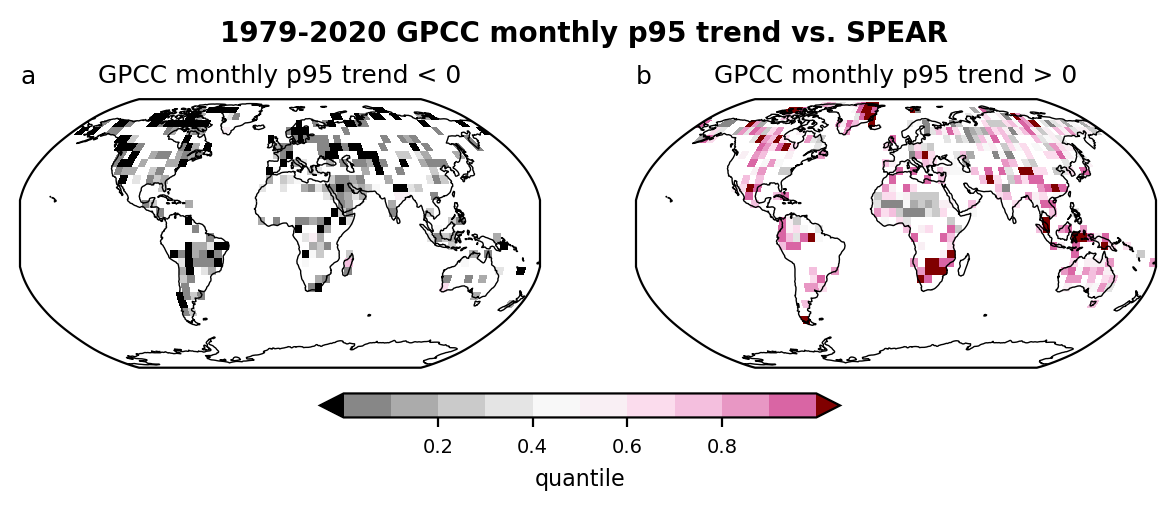

In [127]:
fig = plt.figure(figsize = (w_tot, h_tot))

## ROW 1
ax = fig.add_axes([.03, 0.2, w, h], projection = ccrs.Robinson())
ax.text(0, 1.06, "a", size = titlesize, transform = ax.transAxes)
ax.set_title("GPCC monthly p95 trend < 0", size = titlesize)
p = plot_map(xr.where(gpcc_trend_percent < 0, ecdf_mon_spear_gpcc, np.nan), 
             gpcc_trend_percent.lon, gpcc_trend_percent.lat, ax = ax, label = "quantile", 
         CMAP = pugy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
p.cmap.set_over("maroon")
p.cmap.set_under('black')

ax = fig.add_axes([.11+w, 0.2, w, h], projection = ccrs.Robinson())
ax.text(0, 1.06, "b", size = titlesize, transform = ax.transAxes)
ax.set_title("GPCC monthly p95 trend > 0", size = titlesize)
p = plot_map(xr.where(gpcc_trend_percent > 0, ecdf_mon_spear_gpcc, np.nan), 
             gpcc_trend_percent.lon, gpcc_trend_percent.lat, ax = ax, label = "quantile", 
         CMAP = pugy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
p.cmap.set_over("maroon")
p.cmap.set_under('black')

cbaxes = fig.add_axes([.28, 0.15, w, 0.05]) 
cbar = fig.colorbar(p, cax = cbaxes, orientation = "horizontal", extend = "both")
cbar.set_label(label = 'quantile', size = 8)
cbar.ax.tick_params(labelsize=7)

plt.suptitle("1979-2020 GPCC monthly p95 trend vs. SPEAR", size = 10, fontweight = "bold")

plt.savefig("../figures/ecdf_spear_mon.png", dpi = 600)

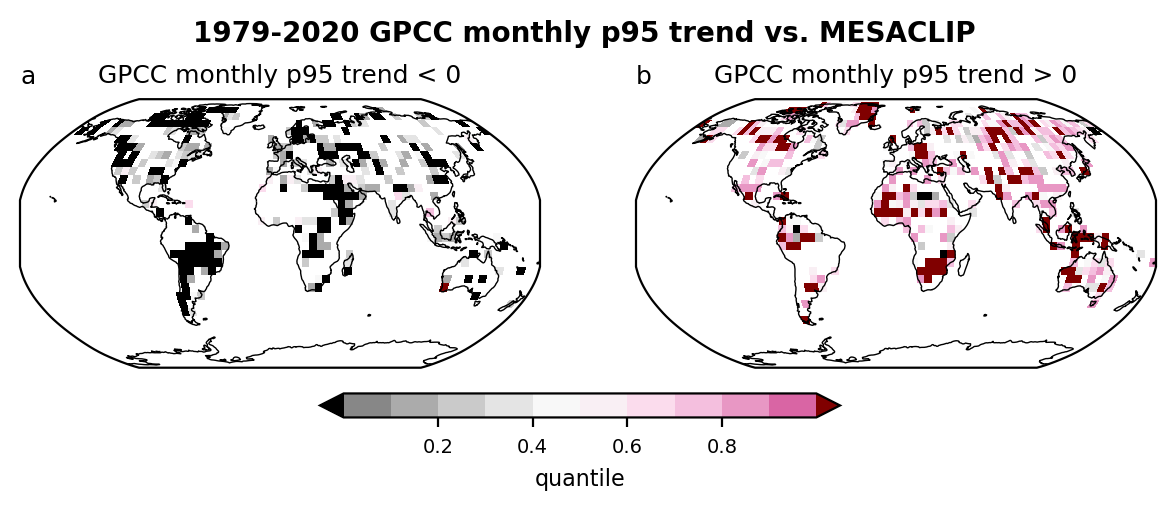

In [128]:
fig = plt.figure(figsize = (w_tot, h_tot))

## ROW 1 
ax = fig.add_axes([.03, 0.2, w, h], projection = ccrs.Robinson())
ax.text(0, 1.06, "a", size = titlesize, transform = ax.transAxes)
ax.set_title("GPCC monthly p95 trend < 0", size = titlesize)
p = plot_map(xr.where(gpcc_trend_percent < 0, ecdf_mon_mesaclip_gpcc, np.nan), 
             gpcc_trend_percent.lon, gpcc_trend_percent.lat, ax = ax, label = "quantile", 
         CMAP = pugy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
p.cmap.set_over("maroon")
p.cmap.set_under('black')

ax = fig.add_axes([.11+w, 0.2, w, h], projection = ccrs.Robinson())
ax.text(0, 1.06, "b", size = titlesize, transform = ax.transAxes)
ax.set_title("GPCC monthly p95 trend > 0", size = titlesize)
p = plot_map(xr.where(gpcc_trend_percent > 0, ecdf_mon_mesaclip_gpcc, np.nan), 
             gpcc_trend_percent.lon, gpcc_trend_percent.lat, ax = ax, label = "quantile", 
         CMAP = pugy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
p.cmap.set_over("maroon")
p.cmap.set_under('black')

cbaxes = fig.add_axes([.28, 0.15, w, 0.05]) 
cbar = fig.colorbar(p, cax = cbaxes, orientation = "horizontal", extend = "both")
cbar.set_label(label = 'quantile', size = 8)
cbar.ax.tick_params(labelsize=7)

plt.suptitle("1979-2020 GPCC monthly p95 trend vs. MESACLIP", size = 10, fontweight = "bold")

plt.savefig("../figures/ecdf_mesaclip_mon.png", dpi = 600)

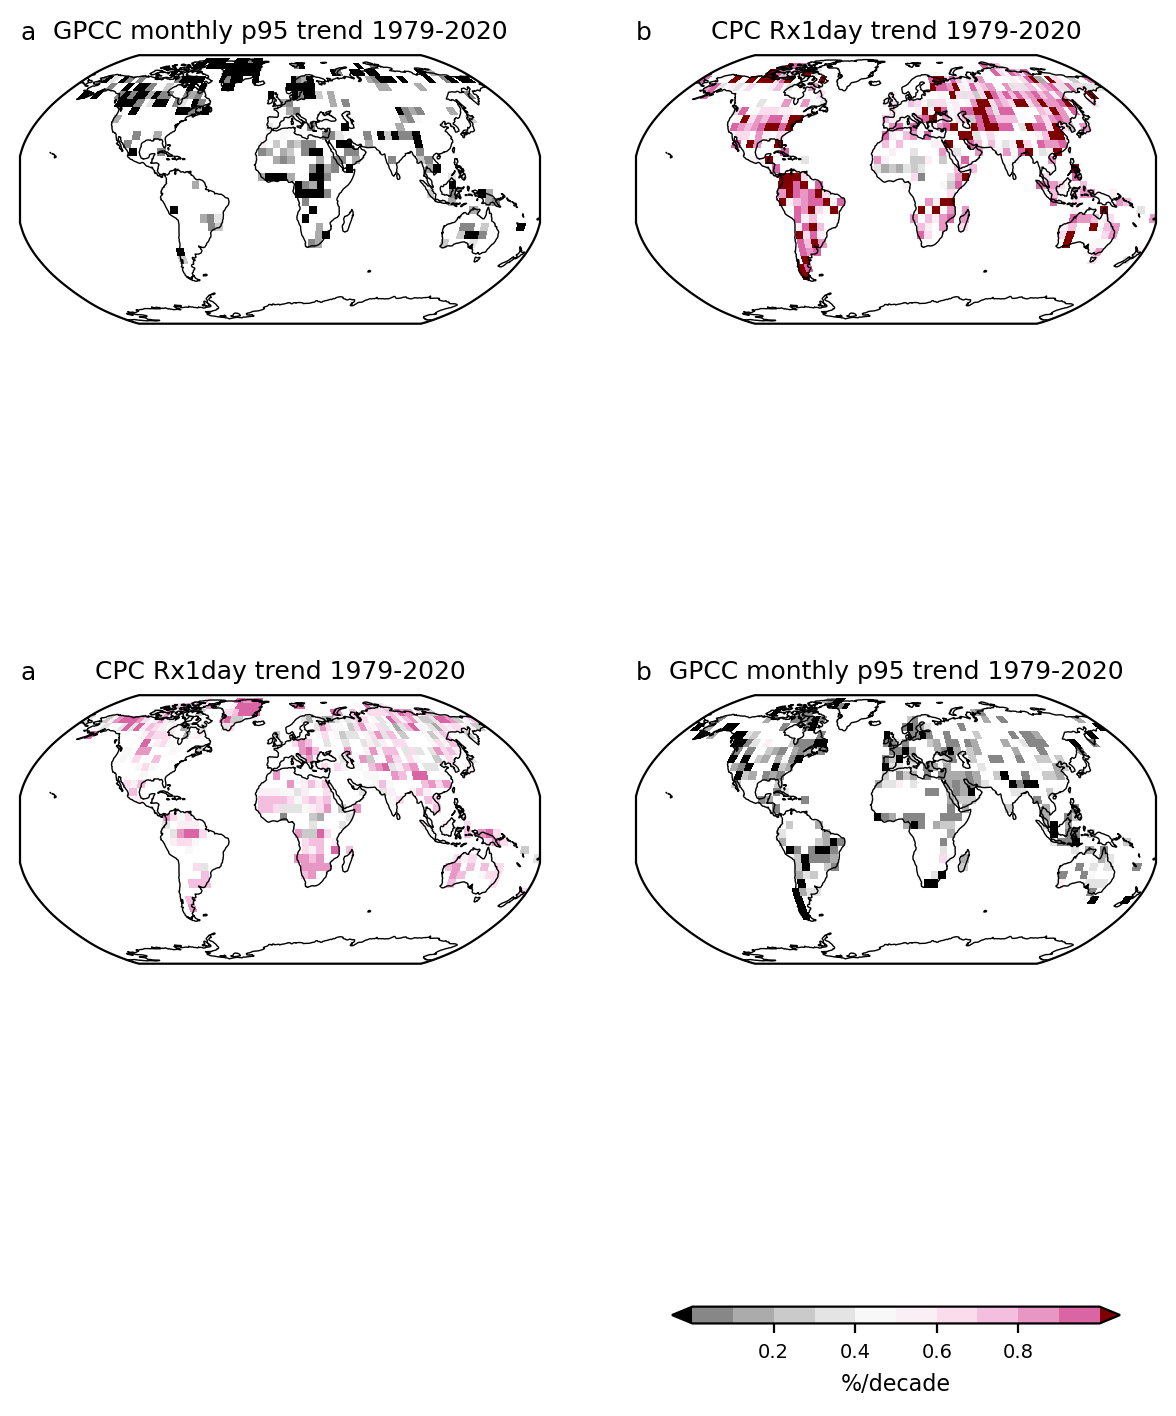

In [30]:
h_tot = 7
h = 1.6/h_tot
w_tot = 6
w = 2.6/w_tot

labelsize = 9
titlesize = 9

fig = plt.figure(figsize = (w_tot, h_tot))

## ROW 1 - Rx1day ECDF Maps
ax = fig.add_axes([.04, h*3+0.07, w, h], projection = ccrs.Robinson())
ax.text(0, 1.06, "a", size = titlesize, transform = ax.transAxes)
ax.set_title("GPCC monthly p95 trend 1979-2020", size = titlesize)
p = plot_map(xr.where(cpc_trend_percent < 0, ecdf_cmip_day, np.nan), 
             cpc_trend_percent.lon, cpc_trend_percent.lat, ax = ax, label = "quantile", 
         CMAP = pugy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
p.cmap.set_over("maroon")
p.cmap.set_under('black')

ax = fig.add_axes([.12+w, h*3+0.07, w, h], projection = ccrs.Robinson())
ax.set_title("CPC Rx1day trend 1979-2020", size = titlesize)
ax.text(0, 1.06, "b", size = titlesize, transform = ax.transAxes)
p = plot_map(xr.where(cpc_trend_percent > 0, ecdf_cmip_day, np.nan), 
             cpc_trend_percent.lon, cpc_trend_percent.lat, ax = ax, label = "quantile", 
         CMAP = pugy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
p.cmap.set_over("maroon")
p.cmap.set_under('black')

cbaxes = fig.add_axes([.15+w, 0.06, w-0.06, 0.012]) 
cbar = fig.colorbar(p, cax = cbaxes, orientation = "horizontal", extend = "both")
cbar.set_label(label = '%/decade', size = 8)
cbar.ax.tick_params(labelsize=7)

## ROW 3 - p95 monthly ECDF Maps
ax = fig.add_axes([.04, h+0.07, w, h], projection = ccrs.Robinson())
ax.set_title("CPC Rx1day trend 1979-2020", size = titlesize)
ax.text(0, 1.06, "a", size = titlesize, transform = ax.transAxes)
p = plot_map(xr.where(gpcp_trend_percent.sel(lat = slice(-58.75, 88.75)) > 0, ecdf_cmip_mon, np.nan), 
             ecdf_cmip_mon.lon, ecdf_cmip_mon.lat, ax = ax, label = "quantile", 
         CMAP = pugy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
p.cmap.set_over("maroon")
p.cmap.set_under('black')

ax = fig.add_axes([.12+w, h+0.07, w, h], projection = ccrs.Robinson())
ax.text(0, 1.06, "b", size = titlesize, transform = ax.transAxes)
ax.set_title("GPCC monthly p95 trend 1979-2020", size = titlesize)
p = plot_map(xr.where(gpcp_trend_percent.sel(lat = slice(-58.75, 88.75)) < 0, ecdf_cmip_mon, np.nan), 
             ecdf_cmip_mon.lon, ecdf_cmip_mon.lat, ax = ax, label = "quantile", 
         CMAP = pugy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
p.cmap.set_over("maroon")
p.cmap.set_under('black')


plt.savefig("../figures/fig2.pdf")

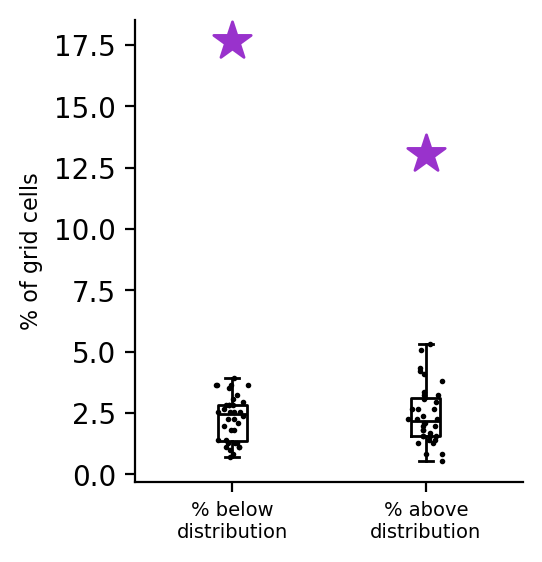

In [40]:
fig, ax = plt.subplots(figsize = (2.5, 3))

box = ax.boxplot(np.array(ecdf_day_test_cmip.ecdf_0)/713*100, whis = (0,100), positions = [0])
ax.scatter(0, (ecdf_day_cmip_cpc == 0).sum().values/713*100,
           marker = "*", s = 200, color = "darkorchid")
box['medians'][0].set_color('black')  # Change to the desired color

box = ax.boxplot(ecdf_day_test_cmip.ecdf_1/713*100, whis = (0,100))
ax.scatter(1, (ecdf_day_cmip_cpc == 1).sum().values/713*100,
           marker = "*", s = 200, color = "darkorchid")
box['medians'][0].set_color('black')  # Change to the desired color

x0 = np.random.normal(0, 0.04, size=len(ecdf_day_test_cmip.ecdf_0))  # Add slight jitter
x1 = np.random.normal(1, 0.04, size=len(ecdf_day_test_cmip.ecdf_0))
ax.scatter(x0, np.array(ecdf_day_test_cmip.ecdf_0)/713*100,s=1, color='black')
ax.scatter(x1, np.array(ecdf_day_test_cmip.ecdf_1)/713*100,s=1, color='black')

ax.set_ylabel("% of grid cells", size = 8)
#ax.set_title("percent of locations with Rx1day trend outside ensemble distribution")
plt.xticks([0, 1], labels = ["% below\ndistribution", "% above\ndistribution"], size = 7);

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

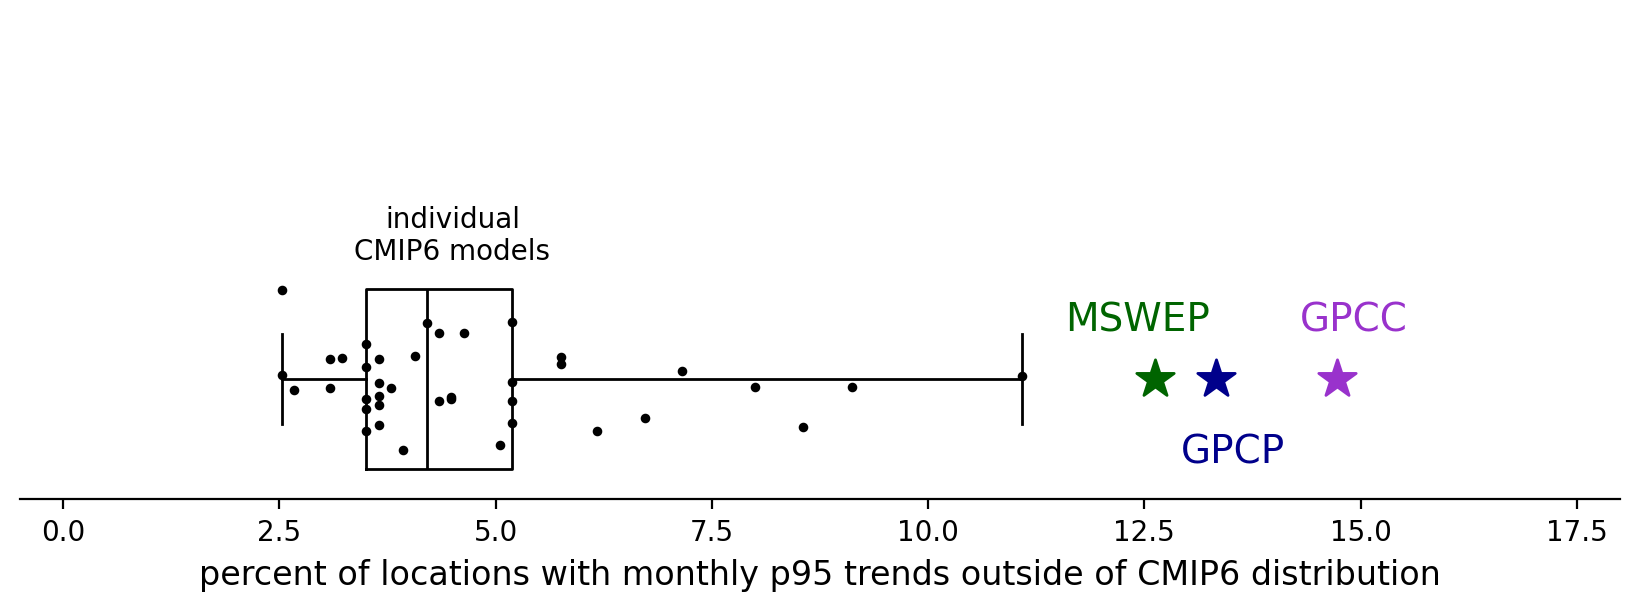

In [76]:
fig = plt.figure(figsize = (10, 3))

ax = fig.add_axes([0.1, 0.2, 0.8, 0.8])
box = ax.boxplot(ecdf_mon_test_cmip.ecdf_1/713*100+ecdf_mon_test_cmip.ecdf_0/713*100, vert=False, whis = (0,100))
ax.scatter((ecdf_mon_cmip_gpcc == 1).sum().values/713*100+(ecdf_mon_cmip_gpcc == 0).sum().values/713*100, 1, 
           marker = "*", s = 200, color = "darkorchid")
ax.scatter((ecdf_mon_cmip_gpcp == 1).sum().values/713*100+(ecdf_mon_cmip_gpcp == 0).sum().values/713*100, 1, 
           marker = "*", s = 200, color = "darkblue")
ax.scatter((ecdf_mon_cmip_mswep == 1).sum().values/713*100+(ecdf_mon_cmip_mswep == 0).sum().values/713*100, 1, 
           marker = "*", s = 200, color = "darkgreen")
ax.text((ecdf_mon_cmip_gpcp == 1).sum().values/713*100+(ecdf_mon_cmip_gpcp == 0).sum().values/713*100+0.2, 0.93, 
        "GPCP", color = "darkblue", ha = "center", size = 14)
ax.text((ecdf_mon_cmip_gpcc == 1).sum().values/713*100+(ecdf_mon_cmip_gpcc == 0).sum().values/713*100+0.2, 1.04, 
        "GPCC", color = "darkorchid", ha = "center", size = 14)
ax.text((ecdf_mon_cmip_mswep == 1).sum().values/713*100+(ecdf_mon_cmip_mswep == 0).sum().values/713*100-0.2, 1.04, 
        "MSWEP", color = "darkgreen", ha = "center", size = 14)
ax.text(4.5, 1.1, "individual\nCMIP6 models", color = "black", ha = "center")
ax.set(ylim = (0.9, 1.3), xlim = (-0.005*100, 0.18*100))
ax.set_xlabel("percent of locations with monthly p95 trends outside of CMIP6 distribution", fontsize = 12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.tick_params(
    axis='y',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected      # ticks along the bottom edge are off
    top=False,  
    left=False, labelleft=False)# ticks along the top edge are off)

x = np.random.normal(1, 0.03, size=len(ecdf_mon_test_cmip.ecdf_1))  # Add slight jitter
ax.scatter(ecdf_mon_test_cmip.ecdf_1/713*100+ecdf_mon_test_cmip.ecdf_0/713*100, x, s=6, color='black')

box['medians'][0].set_color('black')  # Change to the desired color
plt.savefig("../figures/monthly_frequency_test.pdf")

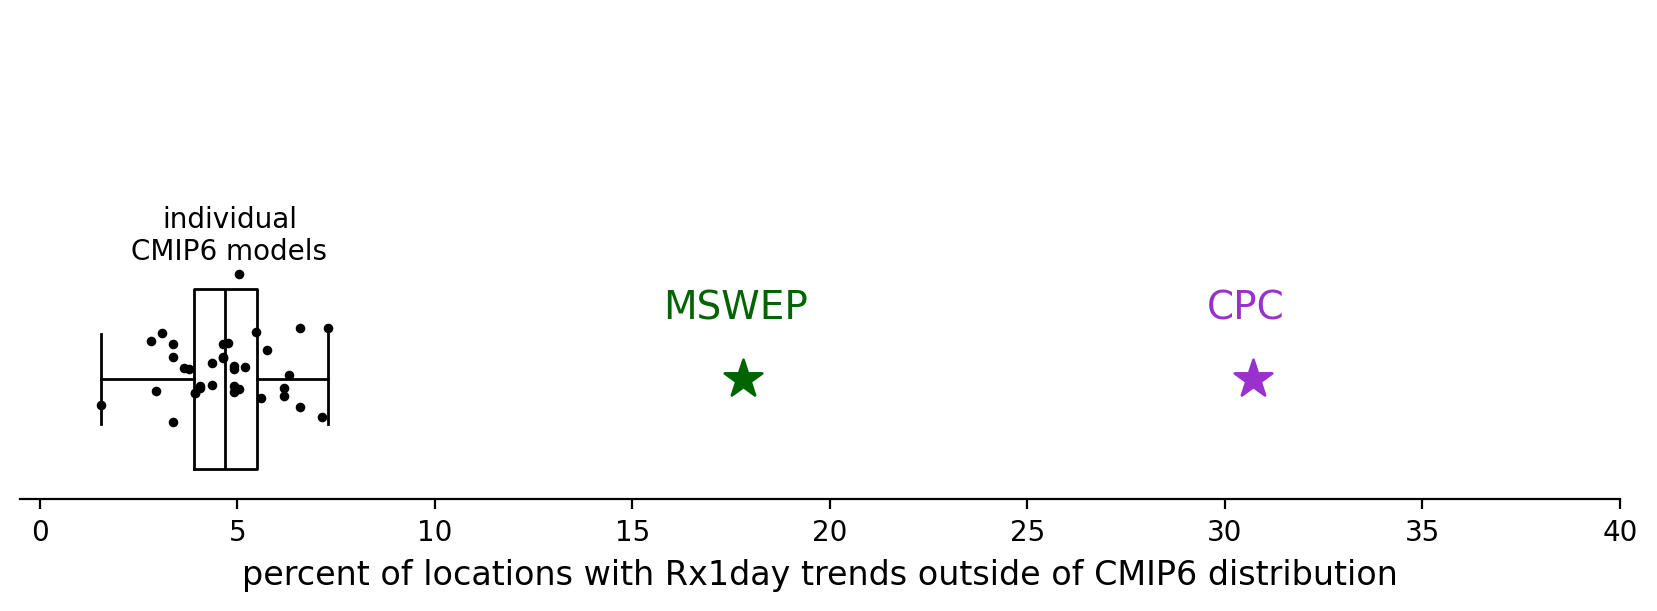

In [77]:
fig = plt.figure(figsize = (10, 3))

ax = fig.add_axes([0.1, 0.2, 0.8, 0.8])

box = ax.boxplot(ecdf_day_test_cmip.ecdf_1/713*100+ecdf_day_test_cmip.ecdf_0/713*100, vert=False, whis = (0,100))
ax.scatter((ecdf_day_cmip_cpc == 1).sum().values/713*100+(ecdf_day_cmip_cpc == 0).sum().values/713*100, 1, 
           marker = "*", s = 200, color = "darkorchid")
ax.scatter((ecdf_day_cmip_mswep == 1).sum().values/713*100+(ecdf_day_cmip_mswep == 0).sum().values/713*100, 1, 
           marker = "*", s = 200, color = "darkgreen")
ax.text((ecdf_day_cmip_cpc == 1).sum().values/713*100+(ecdf_day_cmip_cpc == 0).sum().values/713*100-0.2, 1.05, 
        "CPC", color = "darkorchid", ha = "center", size = 14)
ax.text((ecdf_day_cmip_mswep == 1).sum().values/713*100+(ecdf_day_cmip_mswep == 0).sum().values/713*100-0.2, 1.05, 
        "MSWEP", color = "darkgreen", ha = "center", size = 14)
ax.text(4.8, 1.1, "individual\nCMIP6 models", color = "black", ha = "center")
ax.set(ylim = (0.9, 1.3), xlim = (-0.005*100, 0.40*100))
ax.set_xlabel("percent of locations with Rx1day trends outside of CMIP6 distribution", fontsize = 12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.tick_params(
    axis='y',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected      # ticks along the bottom edge are off
    top=False,  
    left=False, labelleft=False)# ticks along the top edge are off)

x = np.random.normal(1, 0.03, size=len(ecdf_day_test_cmip.ecdf_1))  # Add slight jitter
ax.scatter(ecdf_day_test_cmip.ecdf_1/713*100+ecdf_day_test_cmip.ecdf_0/713*100, x, s=6, color='black')

box['medians'][0].set_color('black')  # Change to the desired color
plt.savefig("../figures/rx1day_frequency_test.pdf")

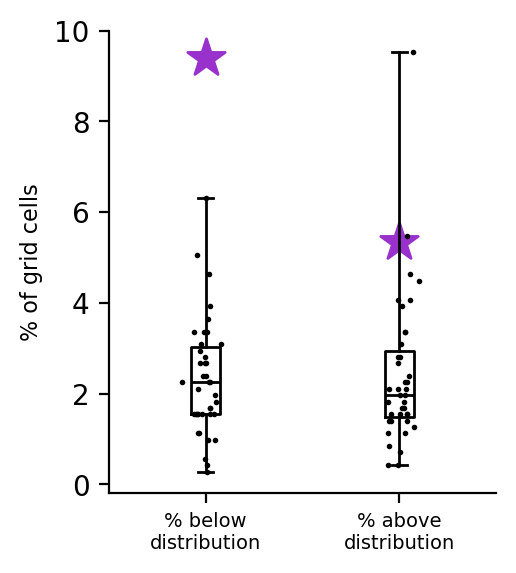

In [41]:
fig, ax = plt.subplots(figsize = (2.5, 3))

box = ax.boxplot(np.array(ecdf_mon_test_cmip.ecdf_0)/713*100, whis = (0,100), positions = [0])
ax.scatter(0, (ecdf_mon_cmip_gpcc == 0).sum().values/713*100,
           marker = "*", s = 200, color = "darkorchid")
box['medians'][0].set_color('black')  # Change to the desired color

box = ax.boxplot(ecdf_mon_test_cmip.ecdf_1/713*100, whis = (0,100))
ax.scatter(1, (ecdf_mon_cmip_gpcc == 1).sum().values/713*100,
           marker = "*", s = 200, color = "darkorchid")
box['medians'][0].set_color('black')  # Change to the desired color

x0 = np.random.normal(0, 0.04, size=len(ecdf_mon_test_cmip.ecdf_0))  # Add slight jitter
x1 = np.random.normal(1, 0.04, size=len(ecdf_mon_test_cmip.ecdf_0))
ax.scatter(x0, np.array(ecdf_mon_test_cmip.ecdf_0)/713*100,s=1, color='black')
ax.scatter(x1, np.array(ecdf_mon_test_cmip.ecdf_1)/713*100,s=1, color='black')

ax.set_ylabel("% of grid cells", size = 8)
#ax.set_title("percent of locations with Rx1day trend outside ensemble distribution")
plt.xticks([0, 1], labels = ["% below\ndistribution", "% above\ndistribution"], size = 7);

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

In [ ]:
fig, ax = plt.subplots(figsize = (2.5, 3))

box = ax.boxplot(np.array(ecdf_0_test)/713*100, whis = (0,100), positions = [0.5])
ax.scatter(0.5, (ecdf_cmip_day == 0).sum().values/713*100,
           marker = "*", s = 200, color = "darkorchid")
box['medians'][0].set_color('black')  # Change to the desired color

box = ax.boxplot(np.array(ecdf_1_test)/713*100, whis = (0,100))
ax.scatter(1, (ecdf_cmip_day == 1).sum().values/713*100,
           marker = "*", s = 200, color = "darkorchid")
box['medians'][0].set_color('black')  # Change to the desired color

x0 = np.random.normal(0.5, 0.04, size=len(ecdf_0_test))  # Add slight jitter
x1 = np.random.normal(1, 0.04, size=len(ecdf_0_test))
ax.scatter(x0, np.array(ecdf_0_test)/713*100,s=1, color='black')
ax.scatter(x1, np.array(ecdf_1_test)/713*100,s=1, color='black')

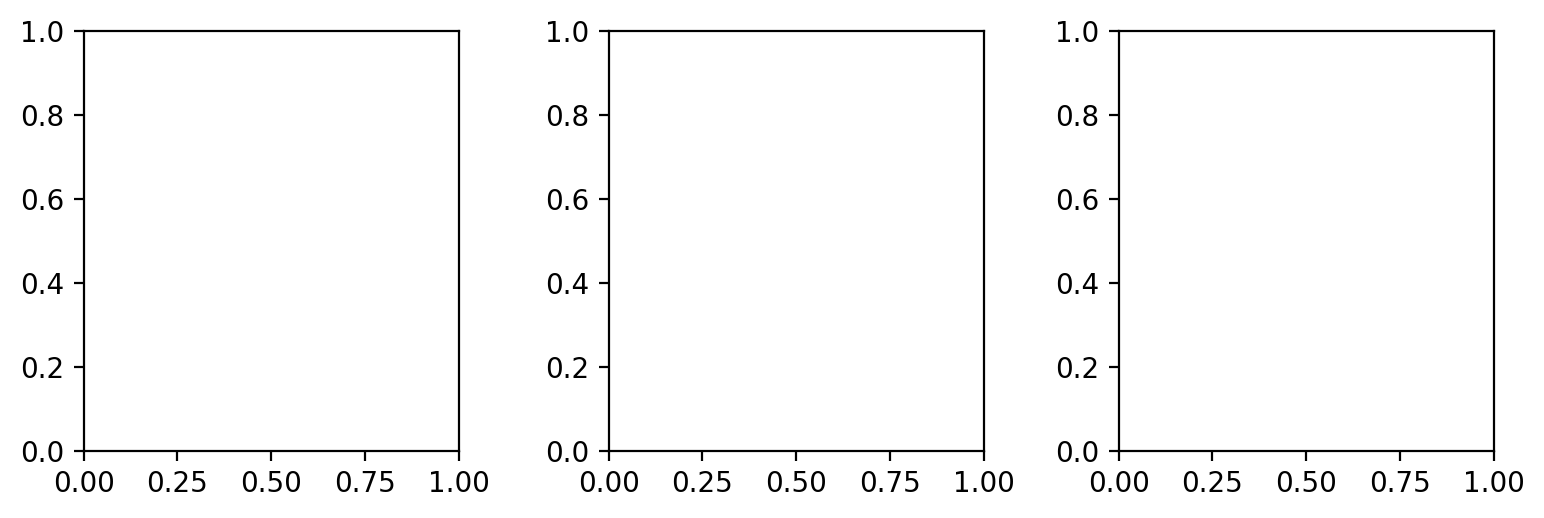

In [97]:
fig = plt.figure(figsize = (7.5, 3))

w = 0.25

ax = fig.add_axes([.05, 0.16, w, 0.7])

ax = fig.add_axes([.15+w, 0.16, w, 0.7])

ax = fig.add_axes([.24+2*w, 0.16, w, 0.7])

plt.savefig("../figures/boxplots.pdf")

In [ ]:
fig, ax = plt.subplots(figsize = (8, 3))

box = ax.boxplot(np.concat(ecdf_1_test)/713*100+np.concat(ecdf_0_test)/713*100, vert=False, whis = (0,100))
ax.scatter((ecdf_mon == 1).sum().values/713*100+(ecdf_mon == 0).sum().values/713*100, 1, 
           marker = "*", s = 200, color = "darkorchid")
ax.scatter((ecdf_gpcp == 1).sum().values/713*100+(ecdf_gpcp == 0).sum().values/713*100, 1, 
           marker = "*", s = 200, color = "darkblue")
ax.text((ecdf_gpcp == 1).sum().values/713*100+(ecdf_gpcp == 0).sum().values/713*100-0.2, 1.05, 
        "GPCP", color = "darkblue", ha = "center", size = 14)
ax.text((ecdf_mon == 1).sum().values/713*100+(ecdf_mon == 0).sum().values/713*100+0.2, 1.05, 
        "GPCC", color = "darkorchid", ha = "center", size = 14)
ax.text(0.7, 1.1, "individual\nCMIP6 models", color = "black", ha = "center")
ax.set(ylim = (0.9, 1.3), xlim = (-0.005*100, 0.15*100))
ax.set_xlabel("percent of locations with trends outside of CMIP6 distribution", fontsize = 12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.tick_params(
    axis='y',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected      # ticks along the bottom edge are off
    top=False,  
    left=False, labelleft=False)# ticks along the top edge are off)

x = np.random.normal(1, 0.03, size=len(ecdf_1_test))  # Add slight jitter
ax.scatter(np.concat(ecdf_1_test)/713*100+np.concat(ecdf_0_test)/713*100, x, s=6, color='black')

plt.tight_layout()
box['medians'][0].set_color('black')  # Change to the desired color
plt.savefig("../figures/monthly_frequency_test.pdf")

In [68]:
len(np.unique(x.values[~np.isnan(x.values)]))

37

In [70]:
print(np.mean(ecdf_1_test))
print(np.mean(ecdf_0_test))

20.166666666666668
16.305555555555557


In [44]:
ecdf_0_test

[array(2),
 array(0),
 array(3),
 array(2),
 array(2),
 array(0),
 array(2),
 array(1),
 array(1),
 array(1),
 array(1),
 array(0),
 array(1),
 array(1),
 array(0),
 array(4),
 array(0),
 array(2),
 array(2),
 array(1),
 array(4),
 array(2),
 array(3),
 array(1),
 array(0),
 array(5),
 array(1),
 array(1),
 array(0),
 array(0),
 array(2),
 array(0),
 array(0),
 array(1),
 array(1),
 array(1)]

In [115]:
ecdf([0, 1, 2, 3, 4, 5, 5, 6]).cdf.evaluate(-1)

array(0.)

In [108]:
ECDF([0, 1, 2, 3, 4, 5, 5, 6])(0)

0.125

In [100]:
import seaborn as sns

(array([ 3.,  4.,  7.,  4., 14.,  7.,  5.,  6.,  7.,  3.,  0.,  5.,  5.,
         6.,  6.,  4., 14.,  6.,  7.,  7.,  3.,  6.,  4.,  1., 13.,  4.,
         3.,  8.,  4.,  5.,  8.,  5.,  8., 10., 10.,  7.,  4.,  7.,  4.,
         4.,  8.,  5.,  5.,  6.,  6.,  8.,  2.,  5.,  3.,  6.,  5.,  6.,
         5.,  5., 10.,  4.,  9.,  7., 12.,  9.,  6.,  8.,  8.,  2.,  8.,
         8.,  8.,  7.,  3.,  3., 11.,  9., 13.,  7.,  5.,  9.,  4.,  5.,
         6., 10., 10., 11.,  8., 13.,  3.,  9., 11.,  8.,  9., 11.,  6.,
        10., 12., 10., 13.,  8., 13., 11., 15., 18.]),
 array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
        0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
        0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
        0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
        0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
        0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.

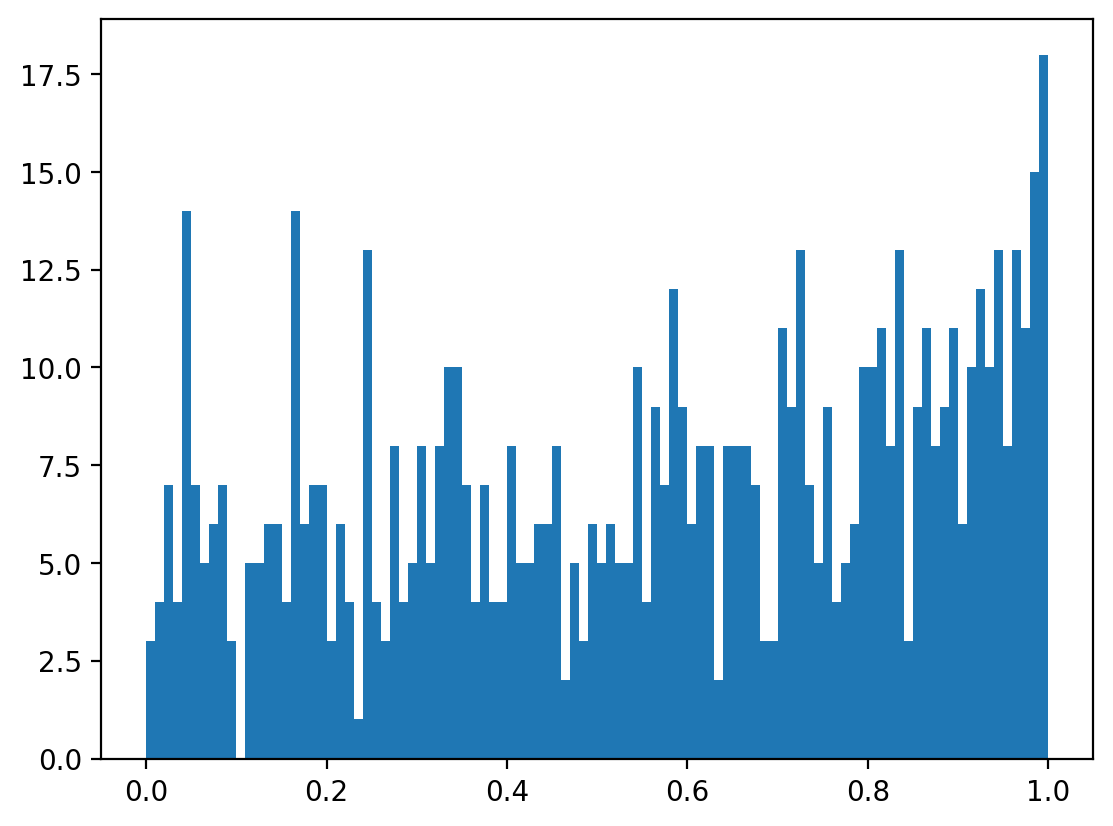

In [104]:
plt.hist(x.values.reshape(-1), bins = 100)

In [97]:
(x == 0).sum()

<xarray.DataArray ()> Size: 8B
array(1)
Coordinates:
    predictions  <U9 36B 'coeff'

In [96]:
ecdf_1_test

[[array(3)],
 [array(4)],
 [array(2)],
 [array(5)],
 [array(4)],
 [array(4)],
 [array(5)],
 [array(4)],
 [array(1)],
 [array(0)],
 [array(4)],
 [array(7)],
 [array(3)],
 [array(3)],
 [array(10)],
 [array(2)],
 [array(2)],
 [array(0)],
 [array(4)],
 [array(1)],
 [array(3)],
 [array(10)],
 [array(10)],
 [array(3)],
 [array(5)],
 [array(2)],
 [array(0)],
 [array(0)],
 [array(1)],
 [array(2)],
 [array(3)],
 [array(18)],
 [array(1)],
 [array(2)],
 [array(8)],
 [array(9)]]

In [81]:
 x = ecdf_xr(cmip_day_trend_percent.drop(labels = mv, dim = "model_variant"), cmip_day_trend_percent.sel(model_variant = mv))

In [82]:
x

<xarray.DataArray (lat: 36, lon: 72)> Size: 21kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * lat          (lat) float64 288B -87.5 -82.5 -77.5 -72.5 ... 77.5 82.5 87.5
  * lon          (lon) float64 576B 2.5 7.5 12.5 17.5 ... 347.5 352.5 357.5
    predictions  <U9 36B 'coeff'

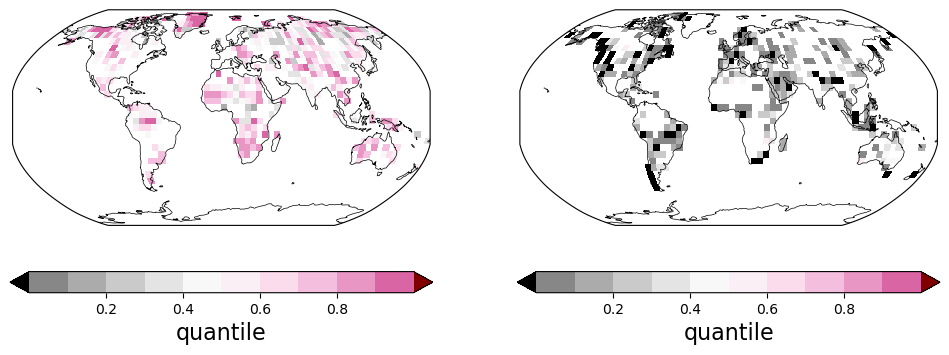

In [22]:
fig, axes = plt.subplots(1, 2, figsize = (12, 4), subplot_kw={"projection": ccrs.Robinson()})

for ax in axes:
    ax.set_extent((-180, 180, -90, 90), crs=ccrs.PlateCarree())

p = plot_map(xr.where(gpcp_trend_percent.sel(lat = slice(-58.75, 88.75)) > 0, ecdf_mon, np.nan), 
             cmip_trends.lon, cmip_trends.lat, ax = axes[0], label = "quantile", 
         CMAP = pugy, VMIN = 0.001, VMAX = 0.999, legend = False)
p.cmap.set_over("maroon")
p.cmap.set_under('black')
cb = plt.colorbar(p, location = "bottom", extend = "both")
cb.set_label(label="quantile",size = 16)

p = plot_map(xr.where(gpcp_trend_percent.sel(lat = slice(-58.75, 88.75)) < 0, ecdf_mon, np.nan),
                      cmip_trends.lon, cmip_trends.lat, ax = axes[1], label = "quantile", 
         CMAP = pugy, VMIN = 0.001, VMAX = 0.999, legend = False)
p.cmap.set_over("maroon")
p.cmap.set_under('black')
cb = plt.colorbar(p, location = "bottom", extend = "both")
cb.set_label(label="quantile",size = 16)

### time series plots

In [51]:
def calc_ecdf(start, ens = "sub"):
    print(start)
    end = 2020
    trend = xr.open_dataset("../processed_data/gpcc_trends/gpcc_mon_"+str(start)+"-"+str(end)+"_5x5_p095_trend.nc")
    stat = xr.open_dataset("../processed_data/gpcc_stats/gpcc_mon_"+str(start)+"-"+str(end)+"_5x5_stats.nc")
    trend_sd = (trend.sel(predictions = "coeff").value*(end-start+1))/stat.p95*100

    files = sorted(glob.glob("../processed_data/cmip_trends/pr_mon_*5x5_"+str(start)+"-"+str(end)+"_p095_trend.nc"))
    mtrend = []
    for f in files:
        x = xr.open_dataset(f).assign_coords({"model_variant": f.split("/")[-1].split("_")[2]+"_"+\
                                                f.split("/")[-1].split("_")[5]})
        try:
            x = x.drop_vars("type")
        except:
            y = 0
        mtrend.append(x)
    mtrend = xr.concat(mtrend, dim = "model_variant")

    files = sorted(glob.glob("../processed_data/cmip_stats/pr_mon_*_5x5_"+str(start)+"-"+str(start+39)+"_stats.nc"))
    mstat = []
    for f in files:
        x = xr.open_dataset(f).assign_coords({"model_variant": f.split("/")[-1].split("_")[2]+"_"+\
                                                f.split("/")[-1].split("_")[5]})
        try:
            x = x.drop_vars("type")
        except:
            y = 0
        mstat.append(x)
    mstat = xr.concat(mstat, dim = "model_variant", coords = "minimal")

    mtrend_sd = (mtrend.sel(predictions = "coeff").value*(end-start+1))/mstat.p95*100

    if ens == "full":
        ecdf_dat = ecdf_xr(mtrend_sd, 
                           trend_sd.sel(lat = slice(-58.75, 88.75)))
    elif ens == "sub": 
        ecdf_dat = ecdf_xr(mtrend_sd.sel(model_variant = onevar_model_keys), 
                           trend_sd.sel(lat = slice(-58.75, 88.75)))

    ## number of positive trends (in each time period)
    summary_dat = pd.DataFrame({"start_year": [start], 
                                "pos_trends": (trend_sd > 0).sum().values,
                                "neg_trends": (trend_sd < 0).sum().values, 
                                "ecdf_1": ((trend_sd > 0) & (ecdf_dat == 1)).sum().values,
                                "ecdf_97.5": ((trend_sd > 0) & (ecdf_dat >= 0.975)).sum().values,
                                "ecdf_0": ((trend_sd < 0) & (ecdf_dat == 0)).sum().values,
                                "ecdf_025": ((trend_sd < 0) & (ecdf_dat <= 0.025)).sum().values, 
                                "ens_mean_pos": (mtrend_sd > 0).sum(dim = ["lat", "lon"]).mean(dim = "model_variant").values,
                                "ens_max_pos": (mtrend_sd > 0).sum(dim = ["lat", "lon"]).max(dim = "model_variant").values,
                                "ens_min_pos":(mtrend_sd > 0).sum(dim = ["lat", "lon"]).min(dim = "model_variant").values})

    return(ecdf_dat, summary_dat)

In [52]:
ecdf_alldates = []
summary_dat = []
for s in np.arange(1930, 1985, 5):
    a, b = calc_ecdf(s, ens = "sub")
    ecdf_alldates.append(a.assign_coords({"start_year": s}))
    summary_dat.append(b)

ecdf_alldates = xr.concat(ecdf_alldates, dim = "start_year", coords = "minimal")
summary_dat = pd.concat(summary_dat)

1930
1935
1940
1945
1950
1955
1960
1965
1970
1975
1980


In [53]:
summary_dat

,start_year,pos_trends,neg_trends,ecdf_1,ecdf_97.5,ecdf_0,ecdf_025,ens_mean_pos,ens_max_pos,ens_min_pos
0,1930,470,243,0,0,64,100,251.943953,602,0
0,1935,444,269,0,0,81,124,254.879056,604,0
0,1940,431,282,0,0,80,116,257.575221,611,0
0,1945,434,279,0,0,89,128,261.283186,604,0
0,1950,414,299,0,0,102,140,265.554572,607,0
0,1955,399,314,0,0,94,139,269.501475,614,0
0,1960,390,323,0,0,70,105,488.427729,611,0
0,1965,402,311,0,0,68,100,490.528024,603,0
0,1970,410,303,0,0,59,97,493.894602,601,0
0,1975,392,321,0,0,61,100,487.843188,591,0


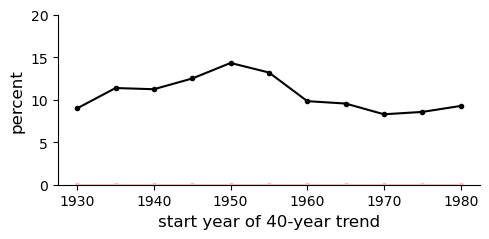

In [54]:
fig, ax = plt.subplots(figsize = (5, 2.5))

ax.plot(summary_dat.start_year, 
        (summary_dat.ecdf_0)/713*100, 
        marker = ".", color = "black")
ax.plot(summary_dat.start_year, 
        (summary_dat.ecdf_1)/713*100, 
        marker = ".", color = "pink")

ax.set(ylim = (0,20))
ax.set_ylabel("percent", fontsize = 12)
ax.set_xlabel("start year of 40-year trend", fontsize = 12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

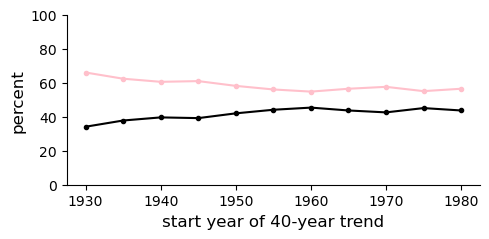

In [55]:
fig, ax = plt.subplots(figsize = (5, 2.5))

ax.plot(summary_dat.start_year, 
        (summary_dat.pos_trends)/713*100, 
        marker = ".", color = "pink")
ax.plot(summary_dat.start_year, 
        (summary_dat.neg_trends)/713*100, 
        marker = ".", color = "black")

ax.set(ylim = (0,100))
ax.set_ylabel("percent", fontsize = 12)
ax.set_xlabel("start year of 40-year trend", fontsize = 12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()